In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.colors import Normalize
from aux_funcs import format_plot

plt.rcParams['font.family'] = 'Helvetica Light'

In [2]:
# ---------------------------------------------------------------------------
# 3-unit ReLU recurrent network
#   h[t+1] = ReLU(W @ h[t] + b + u[t]) + noise
# ---------------------------------------------------------------------------

def relu(x):
    return np.maximum(0.0, x)


def step(h, W, b, u_t, noise_std, rng):
    return relu(W @ h + b + u_t) + rng.normal(0.0, noise_std, size=h.shape)


def simulate(h0, W, b, u, n_steps, noise_std=0.0, rng=None):
    """Simulate from h0 for n_steps steps.

    Parameters
    ----------
    u         : (n_dim,) or (n_steps, n_dim)  constant or time-varying input
    Returns
    -------
    trajectory : (n_steps+1, n_dim)
    """
    if rng is None:
        rng = np.random.default_rng(seed=100)
    u = np.asarray(u, dtype=float)
    if u.ndim == 1:
        u = np.tile(u, (n_steps, 1))
    n_dim = h0.shape[0]
    trajectory = np.zeros((n_steps + 1, n_dim))
    trajectory[0] = h0
    for t in range(n_steps):
        trajectory[t + 1] = step(trajectory[t], W, b, u[t], noise_std, rng)
    return trajectory


In [17]:
def plot_eigenspectrum(W, ax=None):
    """Plot eigenvalues of W on the complex plane with a unit circle."""
    eigenvalues = np.linalg.eigvals(W)
    if ax is None:
        fig, ax = plt.subplots(figsize=(2.5, 2.5))
    else:
        fig = ax.figure
    circle = plt.Circle((0, 0), 1, color='steelblue', fill=False,
                         linestyle='--', linewidth=1)
    ax.add_artist(circle)
    ax.scatter(eigenvalues.real, eigenvalues.imag,
               color='tomato', zorder=5, s=60)
    ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')
    lim = max(1.5, np.abs(eigenvalues).max() * 1.2)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.set_xlabel('Real part')
    ax.set_ylabel('Imaginary part')
    ax.set_title('Eigenspectrum of W')
    format_plot(ax)
    return fig


def plot_weight_matrix(W, b, ax_W=None, ax_b=None):
    """Heatmap of W and b using coolwarm colormap."""
    if ax_W is None:
        fig, (ax_W, ax_b) = plt.subplots(1, 2, figsize=(2.5, 1.25))
    else:
        fig = ax_W.figure
    cmap = sns.diverging_palette(220, 20, s=90, l=65, as_cmap=True)
    vmax = np.abs(W).max()
    im0 = ax_W.imshow(W, cmap=cmap, vmin=-vmax, vmax=vmax)
    ax_W.set_title('W')
    plt.colorbar(im0, ax=ax_W, fraction=0.046, pad=0.04)
    vmax_b = np.abs(b).max() or 1
    im1 = ax_b.imshow(b[:, None], cmap=cmap, vmin=-vmax_b, vmax=vmax_b)
    ax_b.set_title('b')
    plt.colorbar(im1, ax=ax_b, fraction=0.046, pad=0.04)
    format_plot([ax_W, ax_b])
    return fig


def plot_trajectories_3d(trajectories, elev=20, azim=0,
                          figsize=(6, 5), cmap_name='viridis'):
    """3-D state-space trajectories coloured by time.

    Parameters
    ----------
    trajectories : (T, n_inits, n_dim)
    """
    T, n_inits, n_dim = trajectories.shape
    cmap = sns.color_palette(cmap_name, as_cmap=True)
    norm = Normalize(vmin=0, vmax=T - 2)

    fig = plt.figure(figsize=figsize)
    ax  = fig.add_subplot(111, projection='3d')
    dim_max = trajectories.max() * 1.1
    ax.set_xlim(0, dim_max)
    ax.set_ylim(0, dim_max)
    ax.set_zlim(0, dim_max)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('h[0]'); ax.set_ylabel('h[1]'); ax.set_zlabel('h[2]')
    ax.set_title('State-space trajectories')

    for i in range(n_inits):
        traj = trajectories[:, i, :]
        pts  = traj.reshape(-1, 1, 3)
        segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
        lc   = Line3DCollection(segs, cmap=cmap, norm=norm,
                                linewidth=1.2, alpha=0.7)
        lc.set_array(np.arange(T - 1, dtype=float))
        ax.add_collection3d(lc)
        ax.scatter(*traj[0],  s=25, color='green', edgecolors='none', zorder=5)
        ax.scatter(*traj[-1], s=25, color='red',   edgecolors='none', zorder=5)

    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                 ax=ax, label='time step', shrink=0.4, aspect=15)
    plt.tight_layout()
    return fig


def plot_firing_rates(trajectories, u, figsize=(5, None)):
    """Heatmap of external input and each trajectory's firing rates.

    Parameters
    ----------
    trajectories : (T, n_inits, n_dim)
    u            : (T, n_dim)
    """
    T, n_inits, _ = trajectories.shape
    height = figsize[1] or max(3, (n_inits + 1) * 0.5)
    fig, axes = plt.subplots(n_inits + 1, 1,
                             figsize=(figsize[0], height),
                             sharex=True)
    axes[0].imshow(u.T, aspect='auto', cmap='viridis',
                   origin='lower', interpolation='none')
    axes[0].set_ylabel('u', rotation=0, labelpad=12)
    axes[0].set_title('Input u and firing rates')
    for i in range(n_inits):
        axes[i + 1].imshow(trajectories[:, i, :].T, aspect='auto',
                           cmap='viridis', origin='lower', interpolation='none')
        axes[i + 1].set_ylabel(f'#{i}', rotation=0, labelpad=12)
    axes[-1].set_xlabel('time step')
    format_plot(list(axes))
    plt.tight_layout()
    return fig


def analyze_circuit(W, b, u, h0s, n_steps, noise_std=0.0, rng=None, elev=20, azim=0):
    """Run and visualise a 3-unit ReLU RNN circuit.

    Parameters
    ----------
    W         : (3, 3)            recurrent weight matrix
    b         : (3,)              bias vector
    u         : (3,) or (T, 3)   constant or time-varying input
    h0s       : (n_inits, 3)     initial hidden states
    n_steps   : int
    noise_std : float
    rng       : np.random.Generator or None
    """
    if rng is None:
        rng = np.random.default_rng(0)
    u = np.asarray(u, dtype=float)
    if u.ndim == 1:
        u = np.tile(u, (n_steps, 1))

    trajectories = np.stack(
        [simulate(h0, W, b, u, n_steps, noise_std=noise_std, rng=rng)
         for h0 in h0s],
        axis=1,
    )  # (n_steps+1, n_inits, 3)

    for fig in (plot_eigenspectrum(W),
                plot_weight_matrix(W, b),
                plot_trajectories_3d(trajectories, elev=elev, azim=azim),
                plot_firing_rates(trajectories, u)):
        plt.show()

    return trajectories


In [4]:
# ── User configuration ────────────────────────────────────────────────────
s = 1.43
W = np.array([
    [ 1,      1,    -s  ],
    [ 1,      1,     s  ],
    [ s,  -s,    1  ],
]) * 0.5

b = np.array([-0.5, -0.5, -0.5])

n_steps   = 280
noise_std = 0.0
rng       = np.random.default_rng(0)

# Time-varying input: (n_steps, 3) — set to zeros for constant input
u = np.zeros((n_steps, 3))
# u[150:200, :] += np.array([0, 0, 1])
u[:, :] += np.array([0.5, 0.5, 0])

# Initial hidden states: (n_inits, 3)
n_inits = 25
h0s = np.array([1, 1, 0])[None, :] * rng.uniform(0.5, 2, size=(n_inits, 1)) + rng.normal(0.0, 0.1, size=(n_inits, 3))

/tmp/ipykernel_2017466/2563751701.py:107: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


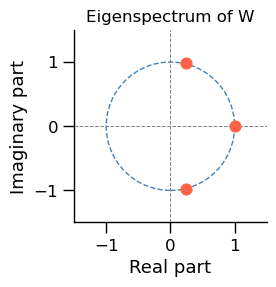

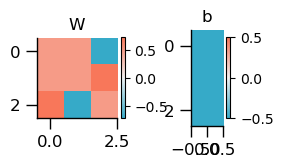

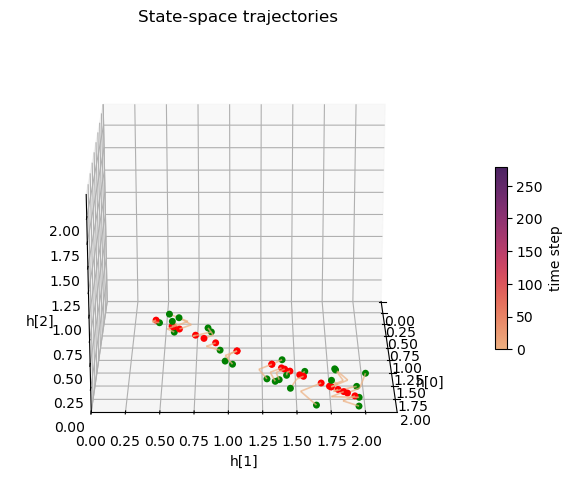

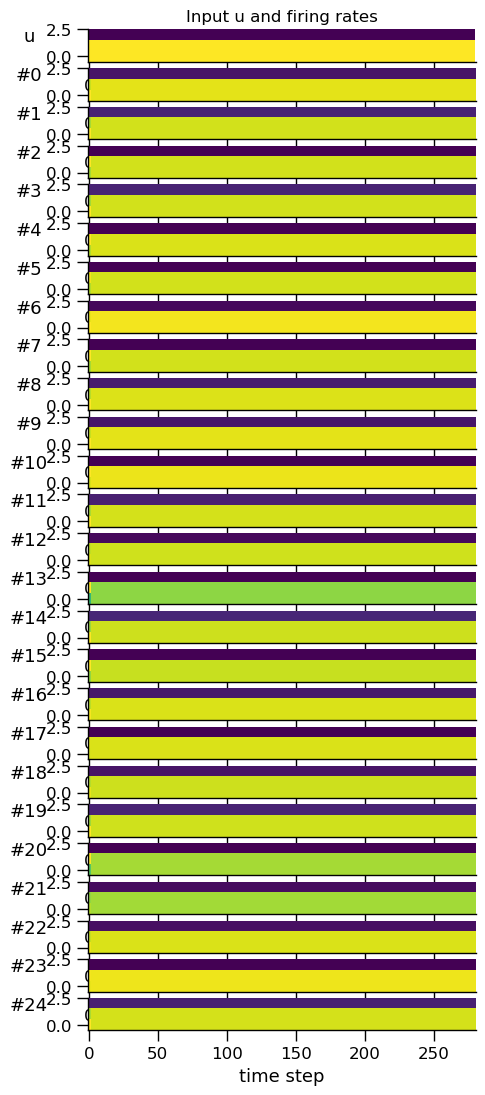

In [87]:
trajectories = analyze_circuit(W, b, u, h0s, n_steps, noise_std, rng)

In [21]:
# ── User configuration ────────────────────────────────────────────────────
s = 1.43
W = np.array([
    [ 1,      1,    -s  ],
    [ 1,      1,     s  ],
    [ s,  -s,    1  ],
]) * 0.5

b = np.array([-0.5, -0.5, -0.5])

n_steps   = 10
noise_std = 0.0
rng       = np.random.default_rng(0)

# Time-varying input: (n_steps, 3) — set to zeros for constant input
u = np.zeros((n_steps, 3))
u[0:4, :] += np.array([0, 0, 1])
u[:, :] += np.array([0.5, 0.5, 0])

# Initial hidden states: (n_inits, 3)
n_inits = 25
h0s = np.array([1, 1, 0])[None, :] * rng.uniform(0.5, 2, size=(n_inits, 1))
# ─────────────────────────────────────────────────────────────────────────


/tmp/ipykernel_411323/297038503.py:107: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


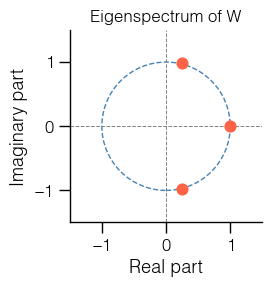

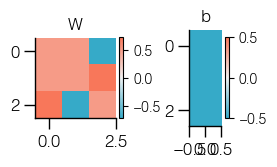

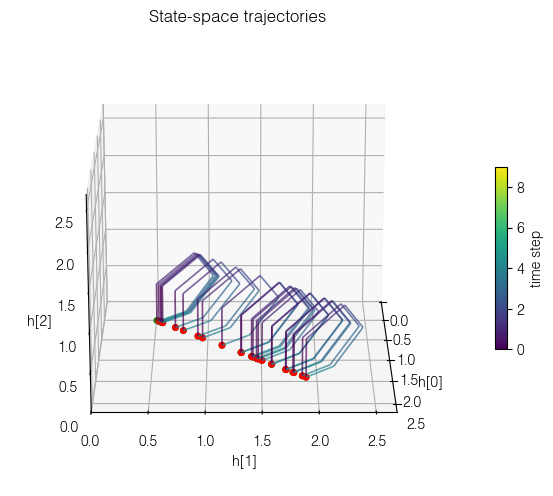

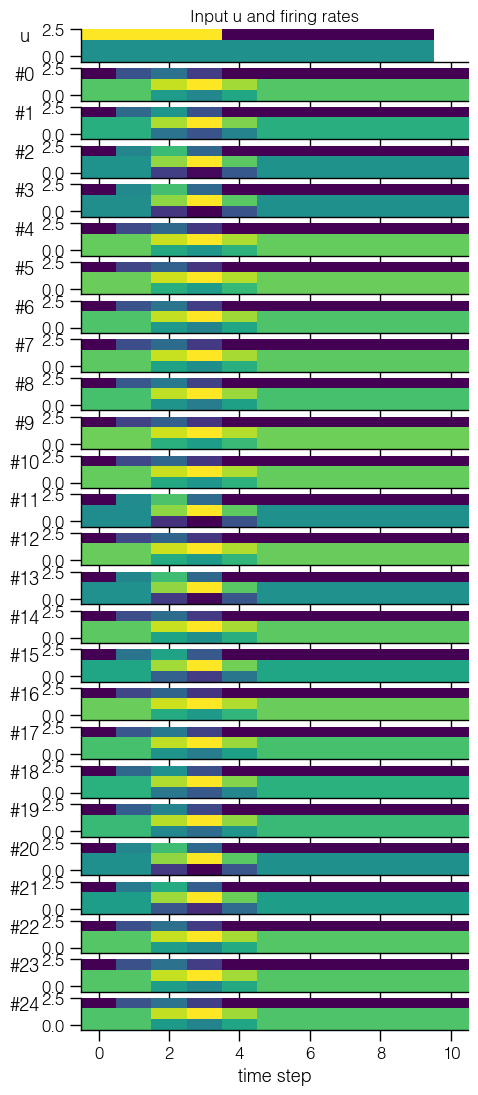

In [22]:
trajectories = analyze_circuit(W, b, u, h0s, n_steps, noise_std, rng)

In [26]:
# ── User configuration ────────────────────────────────────────────────────
s = 1.43
W = np.array([
    [ 1,      1,    -s  ],
    [ 1,      1,     s  ],
    [ s,  -s*1.3,    1  ],
]) * 0.5

b = np.array([-0.5, -0.5, -0.5])

n_steps   = 10
noise_std = 0.0
rng       = np.random.default_rng(0)

# Time-varying input: (n_steps, 3) — set to zeros for constant input
u = np.zeros((n_steps, 3))
# Pulsed input to unit 3 within t = 10..60
n_cycles  = 1
on_steps  = 4
off_steps = 6
for c in range(n_cycles):
    t0 = 0 + c * (on_steps + off_steps)
    u[t0:t0 + on_steps, 2] += 1
u[:, :] += np.array([0.5, 0.5, 0])

# Initial hidden states: (n_inits, 3)
n_inits = 25
h0s = np.array([1, 1, 0])[None, :] * rng.uniform(0.5, 2, size=(n_inits, 1))
# ─────────────────────────────────────────────────────────────────────────


/tmp/ipykernel_411323/297038503.py:107: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


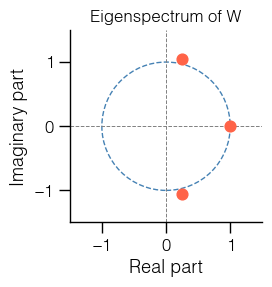

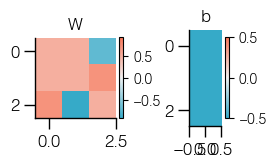

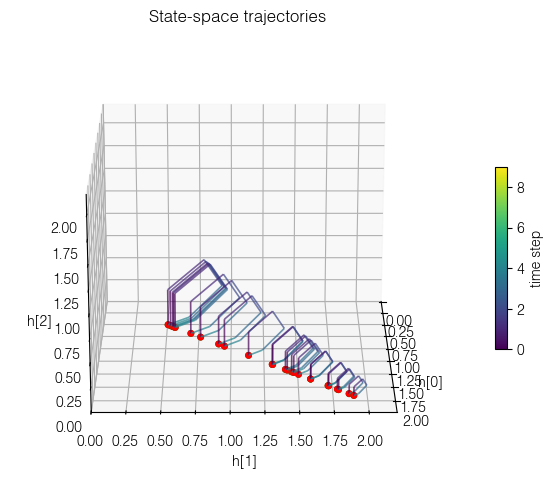

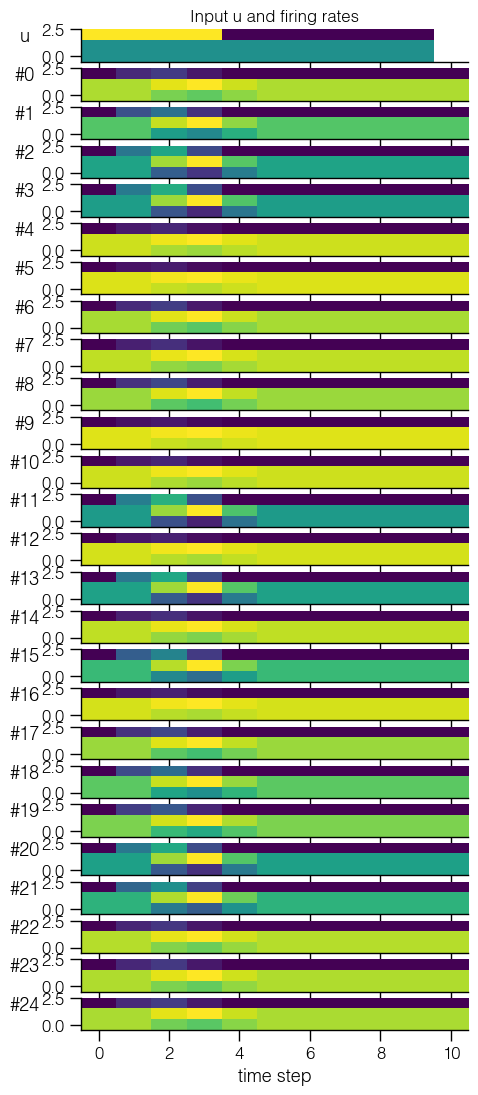

In [27]:
trajectories = analyze_circuit(W, b, u, h0s, n_steps, noise_std, rng)


In [139]:
# ── User configuration ────────────────────────────────────────────────────
s = 1.2
W = np.array([
    [ 1,      1,    -s  ],
    [ 1,      1,     s  ],
    [ s,     -s,     3  ],
]) * 0.5

b = np.array([-0.5, -0.5, -0.5])

n_steps   = 25
noise_std = 0.03
rng       = np.random.default_rng(0)

# Time-varying input: (n_steps, 3) — set to zeros for constant input
u = np.zeros((n_steps, 3))
# Pulsed input to unit 3 within t = 10..60
n_cycles  = 2
on_steps  = 6
off_steps = 3
for c in range(n_cycles):
    t0 = 2 + c * (on_steps + off_steps)
    u[t0:t0 + on_steps, 2] += 1
u[:, :] += np.array([0.5, 0.5, 0])

# Initial hidden states: (n_inits, 3)
n_inits = 5
h0s = np.array([1, 1, 0])[None, :] * np.linspace(2, 4, num=n_inits)[:, None]
# h0s = np.array([1, 1, 0])[None, :] * rng.uniform(2, 4, size=(n_inits, 1))

/tmp/ipykernel_2960867/3741035662.py:107: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


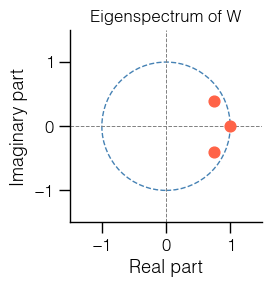

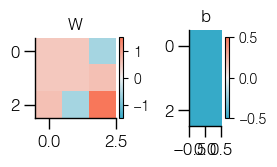

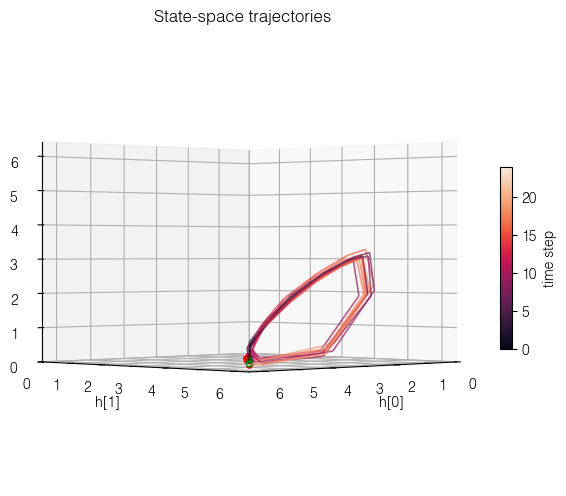

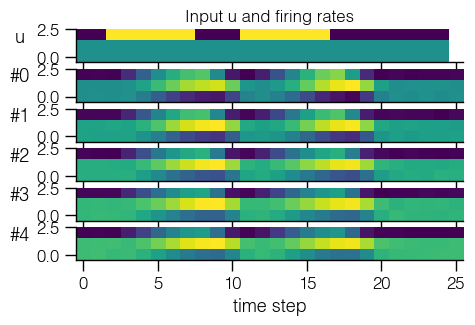

In [140]:
trajectories = analyze_circuit(W, b, u, h0s, n_steps, noise_std, rng, azim=45, elev=0)

/tmp/ipykernel_2960867/3741035662.py:107: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


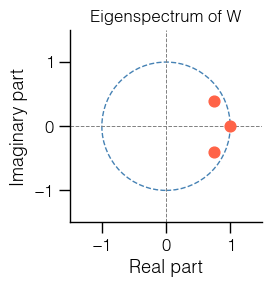

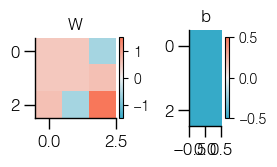

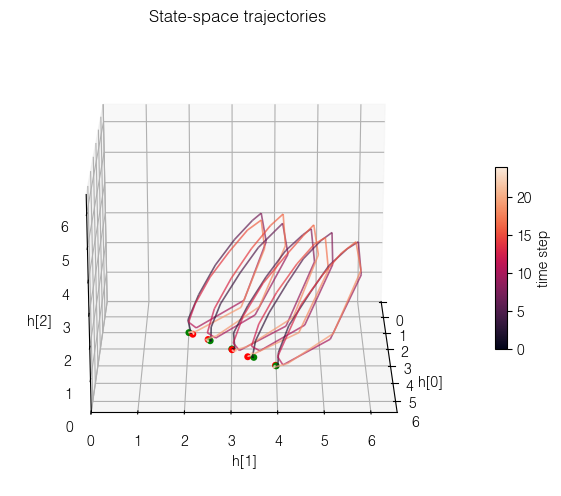

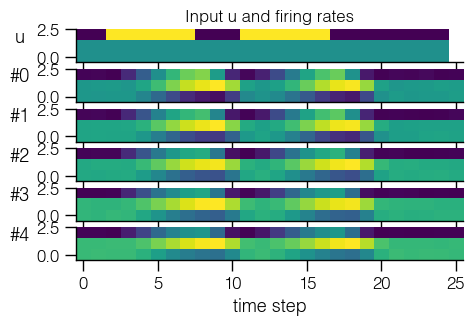

In [141]:
trajectories = analyze_circuit(W, b, u, h0s, n_steps, noise_std, rng, azim=0, elev=20)

In [137]:
# ── User configuration ────────────────────────────────────────────────────
s = 1.2
W = np.array([
    [ 1,      1,    -s  ],
    [ 1,      1,     s  ],
    [ s,     -s,     3  ],
]) * 0.5

b = np.array([-0.5, -0.5, -0.5])

n_steps   = 25
noise_std = 0.03
rng       = np.random.default_rng(0)

# Time-varying input: (n_steps, 3) — set to zeros for constant input
u = np.zeros((n_steps, 3))
# Pulsed input to unit 3 within t = 10..60
n_cycles  = 2
on_steps  = 6
off_steps = 2
for c in range(n_cycles):
    t0 = 2 + c * (on_steps + off_steps)
    u[t0:t0 + on_steps, 2] += 1
u[:, :] += np.array([0.5, 0.5, 0])

# Initial hidden states: (n_inits, 3)
n_inits = 5
h0s = np.array([1, 1, 0])[None, :] * np.linspace(2, 4, num=n_inits)[:, None]
# h0s = np.array([1, 1, 0])[None, :] * rng.uniform(2, 4, size=(n_inits, 1))

/tmp/ipykernel_2960867/3741035662.py:107: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


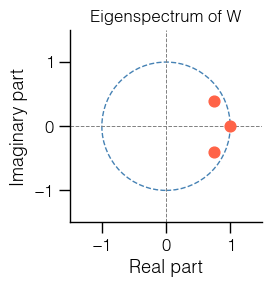

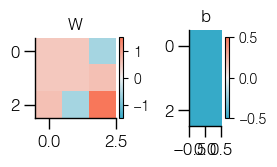

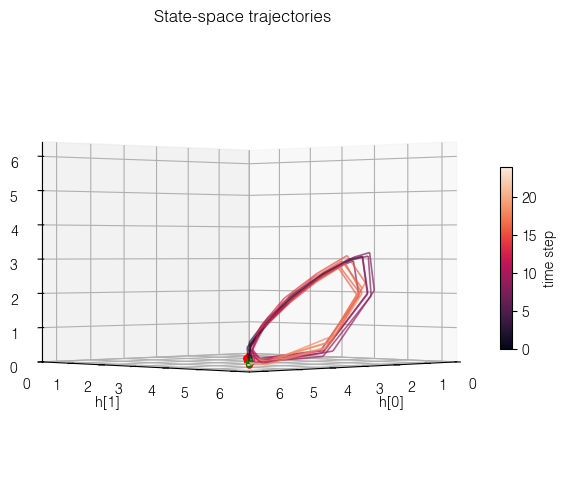

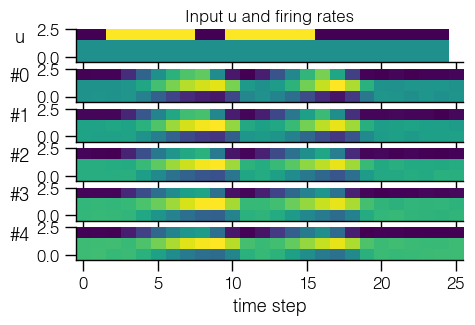

In [138]:
trajectories = analyze_circuit(W, b, u, h0s, n_steps, noise_std, rng, azim=45, elev=0)

In [135]:
# ── User configuration ────────────────────────────────────────────────────
s = 1.2
W = np.array([
    [ 1,      1,    -s  ],
    [ 1,      1,     s  ],
    [ s,     -s,     3  ],
]) * 0.5

b = np.array([-0.5, -0.5, -0.5])

n_steps   = 25
noise_std = 0.03
rng       = np.random.default_rng(0)

# Time-varying input: (n_steps, 3) — set to zeros for constant input
u = np.zeros((n_steps, 3))
# Pulsed input to unit 3 within t = 10..60
n_cycles  = 2
on_steps  = 6
off_steps = 1
for c in range(n_cycles):
    t0 = 2 + c * (on_steps + off_steps)
    u[t0:t0 + on_steps, 2] += 1
u[:, :] += np.array([0.5, 0.5, 0])

# Initial hidden states: (n_inits, 3)
n_inits = 5
h0s = np.array([1, 1, 0])[None, :] * np.linspace(2, 4, num=n_inits)[:, None]
# h0s = np.array([1, 1, 0])[None, :] * rng.uniform(2, 4, size=(n_inits, 1))

/tmp/ipykernel_2960867/3741035662.py:107: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


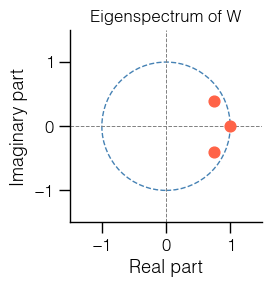

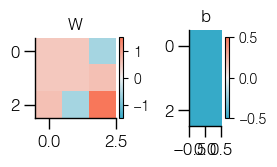

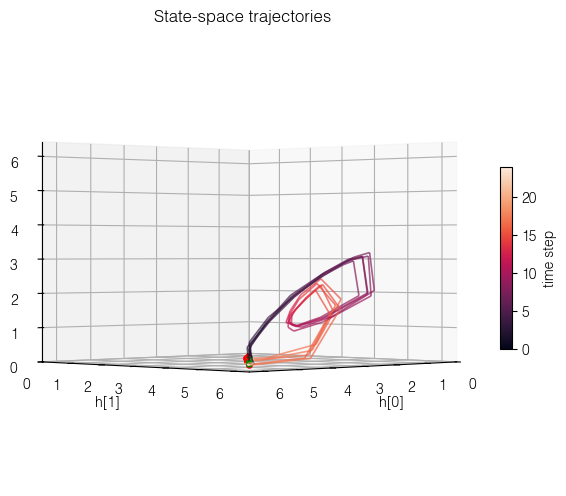

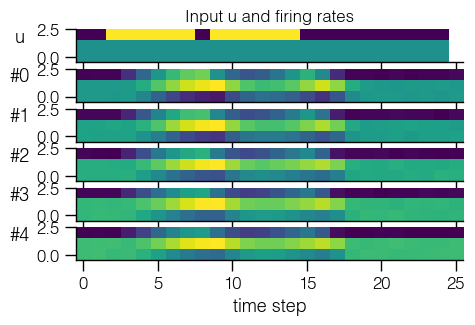

In [136]:
trajectories = analyze_circuit(W, b, u, h0s, n_steps, noise_std, rng, azim=45, elev=0)


In [147]:
# ── User configuration ────────────────────────────────────────────────────
s = 1.2
W = np.array([
    [ 1,      1,    -s  ],
    [ 1,      1,     s  ],
    [ s,     -s * 1.2,     3  ],
]) * 0.5

b = np.array([-0.5, -0.5, -0.5])

n_steps   = 25
noise_std = 0.03
rng       = np.random.default_rng(0)

# Time-varying input: (n_steps, 3) — set to zeros for constant input
u = np.zeros((n_steps, 3))
# Pulsed input to unit 3 within t = 10..60
n_cycles  = 2
on_steps  = 6
off_steps = 1
for c in range(n_cycles):
    t0 = 2 + c * (on_steps + off_steps)
    u[t0:t0 + on_steps, 2] += 1
u[:, :] += np.array([0.5, 0.5, 0])

# Initial hidden states: (n_inits, 3)
n_inits = 5
h0s = np.array([1, 1, 0])[None, :] * np.linspace(2, 4, num=n_inits)[:, None]
# h0s = np.array([1, 1, 0])[None, :] * rng.uniform(2, 4, size=(n_inits, 1))

/tmp/ipykernel_2960867/3741035662.py:107: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


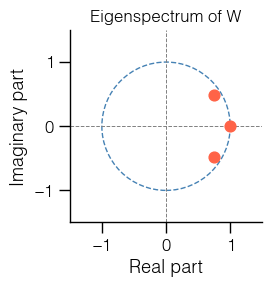

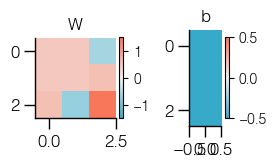

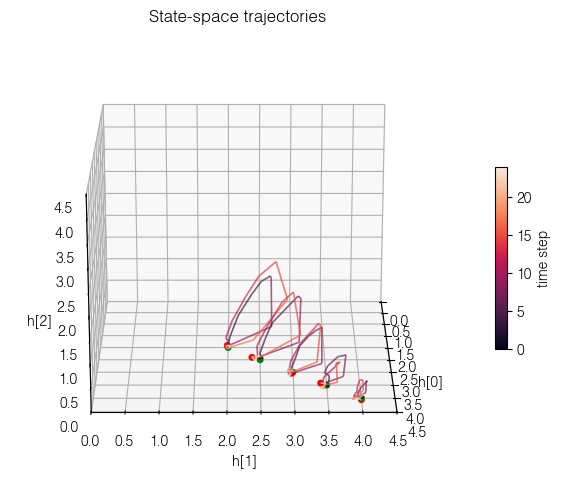

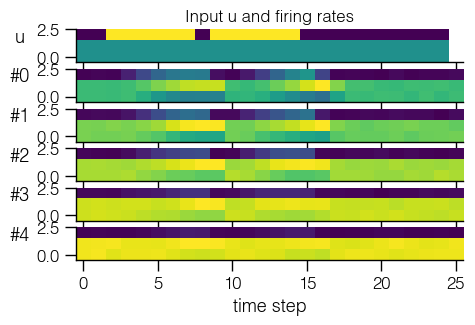

In [148]:
trajectories = analyze_circuit(W, b, u, h0s, n_steps, noise_std, rng, azim=0, elev=20)
